# 04 · Feature Importance

Compare which features drive classification in the **full model** (with redshift) vs the **no-redshift model**.

Key question: *how much does `redshift` dominate, and how does photometry compensate without it?*

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from pathlib import Path

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

# Feature names — must match the order used in prepare_train_test()
FEATURES_FULL = ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta', 'redshift']
FEATURES_NOZ  = ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta']

print('Imports OK')

Imports OK


## Load models

Models must be in memory from `03_models.ipynb`, or loaded from disk if saved with `joblib`.

In [5]:
import joblib
rf_full = joblib.load(OUTPUT_DIR / 'rf_full.pkl')
rf_noz  = joblib.load(OUTPUT_DIR / 'rf_noz.pkl')


imp_full = pd.DataFrame({
    'feature':    FEATURES_FULL,
    'importance': rf_full.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

imp_noz = pd.DataFrame({
    'feature':    FEATURES_NOZ,
    'importance': rf_noz.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Full model — feature importances:')
print(imp_full.to_string(index=False))
print()
print('No-redshift model — feature importances:')
print(imp_noz.to_string(index=False))

Full model — feature importances:
 feature  importance
redshift    0.620450
       z    0.094925
       g    0.081123
       u    0.071752
       i    0.058677
       r    0.055607
   alpha    0.009168
   delta    0.008299

No-redshift model — feature importances:
feature  importance
      z    0.206439
      u    0.195023
      g    0.184953
      r    0.147306
      i    0.141683
  alpha    0.066379
  delta    0.058218


## Plot 1 · RF (full) — Feature Importances

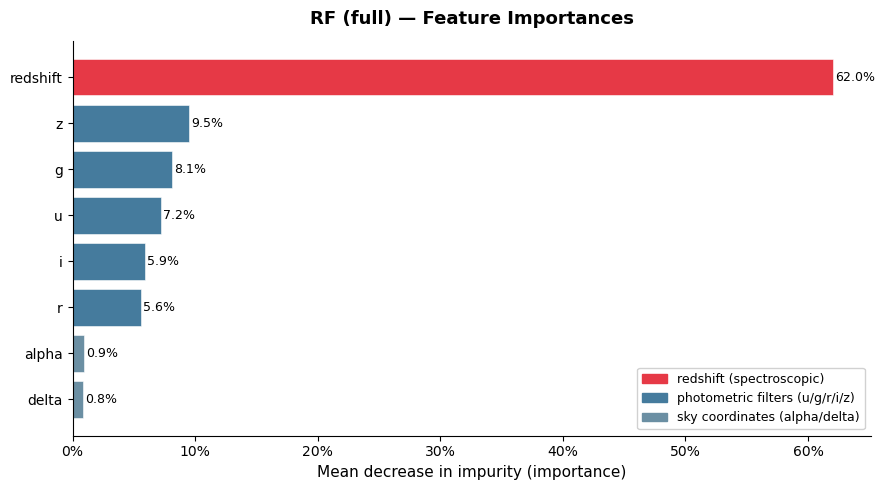

Saved: output/fi_01_full.png


In [6]:
PALETTE_FULL = ['#E63946' if f == 'redshift'
                else '#6B8FA3' if f in ('alpha', 'delta')
                else '#457B9D'
                for f in imp_full['feature']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_full['feature'][::-1], imp_full['importance'][::-1],
               color=PALETTE_FULL[::-1], edgecolor='white', linewidth=0.4)

ax.set_xlabel('Mean decrease in impurity (importance)', fontsize=11)
ax.set_title('RF (full) — Feature Importances', fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{w:.1%}', va='center', fontsize=9)

ax.legend(handles=[
    Patch(color='#E63946', label='redshift (spectroscopic)'),
    Patch(color='#457B9D', label='photometric filters (u/g/r/i/z)'),
    Patch(color='#6B8FA3', label='sky coordinates (alpha/delta)'),
], loc='lower right', framealpha=0.9, fontsize=9)

plt.tight_layout()
path1 = OUTPUT_DIR / 'fi_01_full.png'
fig.savefig(path1, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path1)

## Plot 2 · RF (no redshift) — Feature Importances

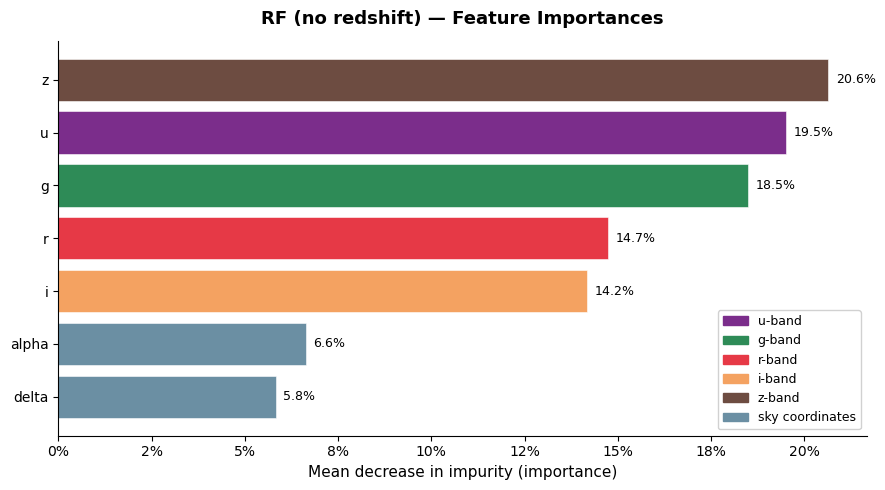

Saved: output/fi_02_noz.png


In [7]:
BAND_COLOURS = {
    'u': '#7B2D8B', 'g': '#2E8B57', 'r': '#E63946',
    'i': '#F4A261', 'z': '#6D4C41',
    'alpha': '#6B8FA3', 'delta': '#6B8FA3'
}

PALETTE_NOZ = [BAND_COLOURS.get(f, '#457B9D') for f in imp_noz['feature']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_noz['feature'][::-1], imp_noz['importance'][::-1],
               color=PALETTE_NOZ[::-1], edgecolor='white', linewidth=0.4)

ax.set_xlabel('Mean decrease in impurity (importance)', fontsize=11)
ax.set_title('RF (no redshift) — Feature Importances', fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{w:.1%}', va='center', fontsize=9)

ax.legend(handles=[
    Patch(color='#7B2D8B', label='u-band'),
    Patch(color='#2E8B57', label='g-band'),
    Patch(color='#E63946', label='r-band'),
    Patch(color='#F4A261', label='i-band'),
    Patch(color='#6D4C41', label='z-band'),
    Patch(color='#6B8FA3', label='sky coordinates'),
], loc='lower right', framealpha=0.9, fontsize=9)

plt.tight_layout()
path2 = OUTPUT_DIR / 'fi_02_noz.png'
fig.savefig(path2, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path2)

## Plot 3 · Side-by-side comparison

Photometric features only — shows how importance redistributes when redshift is removed.

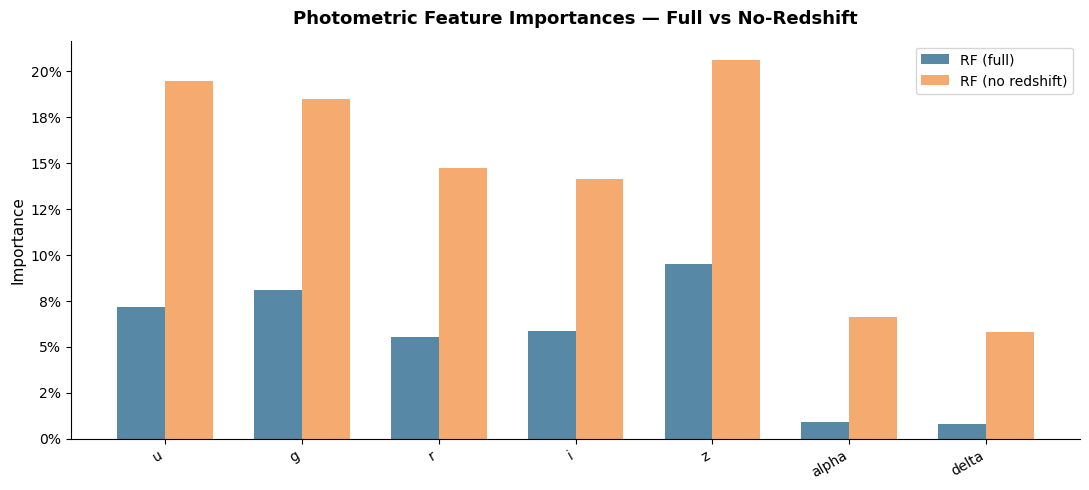

Saved: output/fi_03_comparison.png


In [8]:
common_features = FEATURES_NOZ

vals_full = imp_full.set_index('feature').loc[common_features, 'importance'].values
vals_noz  = imp_noz.set_index('feature').loc[common_features, 'importance'].values

x = np.arange(len(common_features))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, vals_full, width, label='RF (full)',        color='#457B9D', alpha=0.9)
ax.bar(x + width/2, vals_noz,  width, label='RF (no redshift)', color='#F4A261', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(common_features, rotation=30, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel('Importance', fontsize=11)
ax.set_title('Photometric Feature Importances — Full vs No-Redshift',
             fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)

plt.tight_layout()
path3 = OUTPUT_DIR / 'fi_03_comparison.png'
fig.savefig(path3, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path3)

## Save importances to JSON

In [9]:
fi_export = {
    'rf_full': imp_full.set_index('feature')['importance'].round(6).to_dict(),
    'rf_noz':  imp_noz.set_index('feature')['importance'].round(6).to_dict(),
}

out_json = OUTPUT_DIR / 'feature_importances.json'
with open(out_json, 'w') as f:
    json.dump(fi_export, f, indent=2)

print('Saved to', out_json)
print(json.dumps(fi_export, indent=2))

Saved to output/feature_importances.json
{
  "rf_full": {
    "redshift": 0.62045,
    "z": 0.094925,
    "g": 0.081123,
    "u": 0.071752,
    "i": 0.058677,
    "r": 0.055607,
    "alpha": 0.009168,
    "delta": 0.008299
  },
  "rf_noz": {
    "z": 0.206439,
    "u": 0.195023,
    "g": 0.184953,
    "r": 0.147306,
    "i": 0.141683,
    "alpha": 0.066379,
    "delta": 0.058218
  }
}


In [10]:
with open(OUTPUT_DIR / 'fi_summary.txt', 'w') as f:
    f.write('=== RF (full) ===\n')
    f.write(imp_full.to_string(index=False))
    f.write('\n\n=== RF (no redshift) ===\n')
    f.write(imp_noz.to_string(index=False))
print('Saved fi_summary.txt')


Saved fi_summary.txt


## Key takeaways

- In the **full model**, `redshift` is expected to dominate by a large margin — confirming EDA, t-SNE and UMAP findings.
- In the **no-redshift model**, importance redistributes across photometric bands and coordinates.
- The redistribution explains the drop in STAR recall (0.76) and QSO precision (0.79) seen in `03_models.ipynb`.
- These charts form the core narrative: *redshift is the single most informative feature for stellar classification in SDSS DR17.*